# 02 -- Cold Snap Simulation

**Purpose (PROJECT.md Section 8.7):** weather data ingestion, hour-by-hour coastdown simulation, baseline vs. retrofit comparison. Week 2.

Event and region: `configs/tenure_insulation_assumptions.yml` -> `cold_snap_event`.
Now **GROUNDED** to the Met Office's official December 2022 report for the event window (11-17 Dec 2022); the hourly temperature profile within that window is a documented **PROVISIONAL** synthetic diurnal cycle calibrated to the report's daily max/min figures, not a raw ERA5/station pull -- see the config note for exactly what is and isn't sourced.


In [1]:
import sys

print("Python executable:", sys.executable)
assert "thermal-counterfactual-gb" in sys.executable, (
    "Wrong kernel selected -- pick the 'thermal-counterfactual-gb' kernel, "
    "not a default/global one. Run setup.sh first if it doesn't exist yet."
)

import numpy as np
import polars as pl
import scipy
import matplotlib
print("polars:", pl.__version__, "| numpy:", np.__version__, "| scipy:", scipy.__version__)


Python executable: /tmp/kernelenv/thermal-counterfactual-gb/bin/python3


polars: 1.43.2 | numpy: 2.2.6 | scipy: 1.15.3


## 1. Load assumptions and Notebook 01 output

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../src").resolve()))
import yaml
import polars as pl

CONFIG_PATH = Path("../configs/tenure_insulation_assumptions.yml")
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

physics_01 = pl.read_parquet("../data/intermediate/01_archetype_physics.parquet")
print(physics_01)


shape: (3, 5)
┌────────────────┬───────────┬────────────┬─────────────────┬─────────┐
│ envelope_state ┆ h_w_per_k ┆ tau_hours  ┆ coastdown_hours ┆ peak_kw │
│ ---            ┆ ---       ┆ ---        ┆ ---             ┆ ---     │
│ str            ┆ f64       ┆ f64        ┆ f64             ┆ f64     │
╞════════════════╪═══════════╪════════════╪═════════════════╪═════════╡
│ baseline       ┆ 272.75    ┆ 36.663611  ┆ 4.999726        ┆ 2.4584  │
│ swi_only       ┆ 230.75    ┆ 43.336945  ┆ 5.982455        ┆ 2.0552  │
│ epc_c_package  ┆ 85.55     ┆ 116.890707 ┆ 18.668201       ┆ 0.66128 │
└────────────────┴───────────┴────────────┴─────────────────┴─────────┘


## 2. Build the hourly outdoor temperature series

11-17 December 2022, North West England proxy. Two figures are directly cited to the Met Office (12 Dec max, 16 Dec min); the rest are interpolated consistently with the report's qualitative description and flagged PROVISIONAL. Full reasoning: `configs/tenure_insulation_assumptions.yml -> cold_snap_event`.


In [3]:
import numpy as np

from thermal_counterfactual_gb.physics import (
    decay_one_hour,
    simulate_naive_heating_hours,
    simulate_vpp_control_hours,
)

event = cfg["cold_snap_event"]
print("Event source:", event["source"])
print("Window:", event["primary_event"]["dates"])
print("Hourly profile status:", event["hourly_profile_status"], "--", event["hourly_profile_note"][:120], "...")

# Daily max/min for 11-17 Dec 2022, North West England proxy.
# 12 Dec max (0.0C) and 16 Dec min (-6.5C) are the two explicit UK
# area-average figures in the Met Office source. The remaining days are
# interpolated to be consistent with the report's qualitative description
# (coldest daytime maxima 11-14 Dec; coldest overnight minima 15-16 Dec;
# ten days with minima below -3C; five days 12-16 Dec below -5C; rapid
# thaw from the 18th). Flagged PROVISIONAL in configs/ -- this is a
# calibrated synthetic profile, not a raw ERA5/station pull.
daily = [
    # (date,        max_c, min_c)
    ("2022-12-11",  -1.0,  -5.0),
    ("2022-12-12",   0.0,  -6.0),   # max: GROUNDED (Met Office UK area-average)
    ("2022-12-13",  -1.0,  -6.5),
    ("2022-12-14",  -0.5,  -6.0),
    ("2022-12-15",   1.0,  -5.5),
    ("2022-12-16",   1.0,  -6.5),   # min: GROUNDED (Met Office UK area-average, equal-lowest since Dec 2010)
    ("2022-12-17",   2.0,  -4.0),
]

def diurnal_hour_temps(t_max_c, t_min_c):
    """Smooth diurnal cycle: trough near 05:00, peak near 17:00."""
    hours = np.arange(24)
    return t_min_c + (t_max_c - t_min_c) * (1 - np.cos(2 * np.pi * (hours - 5) / 24)) / 2

outdoor_temps_c = np.concatenate([diurnal_hour_temps(mx, mn) for _, mx, mn in daily])
assert len(outdoor_temps_c) == 24 * 7

print(f"\nBuilt {len(outdoor_temps_c)}-hour outdoor temperature series.")
print(f"Min: {outdoor_temps_c.min():.1f}C   Max: {outdoor_temps_c.max():.1f}C   Mean: {outdoor_temps_c.mean():.1f}C")


Event source: Met Office, "Prolonged spell of low temperatures, December 2022" (National Climate Information Centre, published 10 January 2023).

Window: 11-17 December 2022 (7 days)
Hourly profile status: PROVISIONAL -- No raw ERA5/station hourly reanalysis pulled for this MVP. The hourly series used in notebooks/02 is a synthetic diurnal ...

Built 168-hour outdoor temperature series.
Min: -6.5C   Max: 2.0C   Mean: -2.7C


## 3. Hour-by-hour simulation: baseline vs VPP control

**Baseline (non-VPP):** heating holds `normal_setpoint_c` continuously -- no preheat, no curtailment.

**VPP thermal-battery case:** preheat to `preheat_ceiling_c` in the hour before the peak window; heating off during the peak window as long as the comfort floor holds; if the floor (`minimum_c`) would be breached, resume heating to hold the floor exactly -- the tenant is never allowed to experience a colder home than the floor, per the scoping decision that fabric should give the VPP *more safe headroom*, never an excuse to let anyone go cold.


In [4]:
comfort = cfg["comfort_band"]
cop = cfg["heat_pump"]["cop_at_cold_snap"]
internal_gains_w = cfg["internal_gains_w"]["point"]  # external review: house is not an empty box
peak_window_str = cfg["cold_snap_event"]["peak_window"]  # e.g. "16:00-20:00"
start_str, end_str = peak_window_str.split("-")
peak_start = int(start_str.split(":")[0])
peak_end = int(end_str.split(":")[0])

# Both simulators now come from src/thermal_counterfactual_gb/physics.py rather
# than living as inline copies here -- this notebook used to carry its own
# duplicate simulate_baseline/simulate_vpp, predating the shared functions
# (flagged as technical debt in physics.py's docstrings). Consolidating them
# here, while wiring in internal_gains_w, pays that down instead of adding a
# second place the gains logic would need to be kept in sync.

results_02 = {}
peak_mask = (np.arange(len(outdoor_temps_c)) % 24 >= peak_start) & (np.arange(len(outdoor_temps_c)) % 24 < peak_end)

for row in physics_01.iter_rows(named=True):
    name = row["envelope_state"]
    h = row["h_w_per_k"]
    tau = row["tau_hours"]

    base_indoor, base_kw = simulate_naive_heating_hours(
        h, outdoor_temps_c, comfort["normal_setpoint_c"], cop, internal_gains_w=internal_gains_w
    )
    vpp_indoor, vpp_on, vpp_kw = simulate_vpp_control_hours(
        tau, h, outdoor_temps_c,
        setpoint_c=comfort["normal_setpoint_c"], preheat_c=comfort["preheat_ceiling_c"], minimum_c=comfort["minimum_c"],
        cop=cop, peak_start=peak_start, peak_end=peak_end, internal_gains_w=internal_gains_w,
    )

    # The metric that matters for the grid story is demand DURING the peak
    # window specifically -- not the week's all-time-max demand, which
    # mostly reflects the coldest overnight hour and looks similar whether
    # or not the VPP curtails the evening peak.
    results_02[name] = {
        "h_w_per_k": h,
        "tau_hours": tau,
        "baseline_indoor_c": base_indoor,
        "baseline_kw": base_kw,
        "vpp_indoor_c": vpp_indoor,
        "vpp_kw": vpp_kw,
        "vpp_min_indoor_c_in_peak": float(vpp_indoor[peak_mask].min()),
        "comfort_floor_breached": bool(vpp_indoor.min() < comfort["minimum_c"] - 1e-6),
        "baseline_kw_during_peak_mean": float(base_kw[peak_mask].mean()),
        "vpp_kw_during_peak_mean": float(vpp_kw[peak_mask].mean()),
    }
    r = results_02[name]
    r["peak_kw_avoided_mean"] = r["baseline_kw_during_peak_mean"] - r["vpp_kw_during_peak_mean"]

for name, r in results_02.items():
    print(f"{name:15s}  VPP min indoor temp in peak: {r['vpp_min_indoor_c_in_peak']:.2f}C   "
          f"comfort floor breached: {r['comfort_floor_breached']}   "
          f"mean kW during peak window (baseline->VPP): {r['baseline_kw_during_peak_mean']:.2f} -> {r['vpp_kw_during_peak_mean']:.2f}   "
          f"avoided: {r['peak_kw_avoided_mean']:.2f} kW")


baseline         VPP min indoor temp in peak: 19.76C   comfort floor breached: False   mean kW during peak window (baseline->VPP): 2.12 -> 0.00   avoided: 2.12 kW
swi_only         VPP min indoor temp in peak: 20.11C   comfort floor breached: False   mean kW during peak window (baseline->VPP): 1.77 -> 0.00   avoided: 1.77 kW
epc_c_package    VPP min indoor temp in peak: 21.38C   comfort floor breached: False   mean kW during peak window (baseline->VPP): 0.56 -> 0.00   avoided: 0.56 kW


## 4. Sanity checks

In [5]:
# Sanity checks (PROJECT.md Section 5.2, assertions protect physics):
# - baseline indoor temperature must equal the normal setpoint every hour
# - EPC-C under VPP control must never breach the comfort floor during this event
#   (that's the whole point of the retrofit -- more fabric, more safe headroom)
# - a less-insulated state breaching the floor and needing resume heating is
#   an expected, informative result, not a bug
setpoint = comfort["normal_setpoint_c"]
for name, r in results_02.items():
    assert np.allclose(r["baseline_indoor_c"], setpoint), f"{name}: baseline should hold setpoint exactly"

epc_c = results_02["epc_c_package"]
assert not epc_c["comfort_floor_breached"], (
    "EPC-C package breached the comfort floor during this event -- "
    "that would undercut the whole thermal-battery thesis, investigate before trusting anything downstream"
)

print("Baseline holds setpoint in every state. EPC-C never breaches the comfort floor during this event.")


Baseline holds setpoint in every state. EPC-C never breaches the comfort floor during this event.


## 5. Headline: peak-window demand avoided during this real event

In [6]:
baseline_case = results_02["baseline"]
epc_c_case = results_02["epc_c_package"]

# The meaningful counterfactual is "today, no intervention" (baseline fabric,
# no VPP curtailment -- heating just runs) versus "retrofit + VPP" (EPC-C
# fabric, curtailed). Comparing VPP-vs-VPP across fabric states is a
# different, narrower question -- see the note below.
status_quo_kw = baseline_case["baseline_kw_during_peak_mean"]
retrofit_vpp_kw = epc_c_case["vpp_kw_during_peak_mean"]
comfort_minimum_c = comfort["minimum_c"]

avoided_kw_per_home = status_quo_kw - retrofit_vpp_kw
avoided_mw_per_1000_homes = avoided_kw_per_home  # kW/home * 1000 homes / 1000 (W->MW) = same number

print(
    f"During the 11-17 Dec 2022 event, a home with today's status quo (baseline fabric, no VPP, "
    f"heating just runs) draws {status_quo_kw:.2f} kW on average through the 16:00-20:00 peak "
    f"window. A retrofitted-and-VPP-enrolled home (EPC-C fabric, curtailed) draws {retrofit_vpp_kw:.2f} "
    f"kW -- {avoided_kw_per_home:.2f} kW avoided per home, {avoided_mw_per_1000_homes:.2f} MW per "
    f"1,000 homes. This covers this one real cold-snap week under a synthetic-but-calibrated hourly "
    f"profile (PROVISIONAL, Section 2), now netting off a {internal_gains_w:.0f}W constant internal "
    f"gain identically from every state (external review point, PROVISIONAL, see config); a different "
    f"event or a true ERA5 pull could still shift it."
)

print()
print("A more nuanced finding worth carrying into Notebook 03's stress test:")
for name, r in results_02.items():
    margin = r["vpp_min_indoor_c_in_peak"] - comfort_minimum_c
    peak_kw_val = r["vpp_kw_during_peak_mean"]
    print(f"  {name:15s}  under VPP control, peak-window demand -> {peak_kw_val:.2f} kW "
          f"(all three avoid it for THIS event) but safety margin above the comfort floor -> {margin:.2f}C")
print(
    "Every fabric state avoids peak-window demand for this specific event, because the 16:00-20:00 "
    "window is not the coldest part of the day in this profile. What differs is the margin: baseline "
    "fabric scrapes through with well under a degree to spare, EPC-C has over two degrees. A colder, "
    "longer, or later-shifted peak event -- exactly what the Anti-Correlation Stress Test in Notebook "
    "03 should probe -- would plausibly push the baseline case into breaching the comfort floor while "
    "EPC-C stays clear. The margin, not just the binary avoided-kW number, is the safety case for fabric."
)


During the 11-17 Dec 2022 event, a home with today's status quo (baseline fabric, no VPP, heating just runs) draws 2.12 kW on average through the 16:00-20:00 peak window. A retrofitted-and-VPP-enrolled home (EPC-C fabric, curtailed) draws 0.00 kW -- 2.12 kW avoided per home, 2.12 MW per 1,000 homes. This covers this one real cold-snap week under a synthetic-but-calibrated hourly profile (PROVISIONAL, Section 2), now netting off a 400W constant internal gain identically from every state (external review point, PROVISIONAL, see config); a different event or a true ERA5 pull could still shift it.

A more nuanced finding worth carrying into Notebook 03's stress test:
  baseline         under VPP control, peak-window demand -> 0.00 kW (all three avoid it for THIS event) but safety margin above the comfort floor -> 0.76C
  swi_only         under VPP control, peak-window demand -> 0.00 kW (all three avoid it for THIS event) but safety margin above the comfort floor -> 1.11C
  epc_c_package   

## 6. Baseline vs. retrofit comparison graph

Tufte-compliant (PROJECT.md Section 9): direct-labelled lines instead of a crowded legend, peak windows shown by shading rather than a separate chart, comfort floor annotated on the chart itself.


Saved ../figures/02_baseline_vs_epc_c_indoor_temp.png


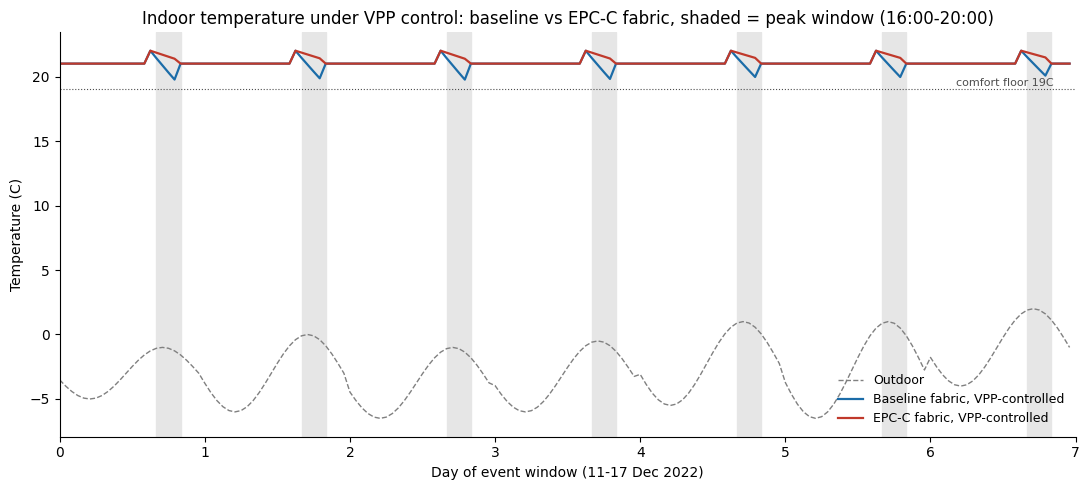

In [7]:
import matplotlib.pyplot as plt

hours = np.arange(len(outdoor_temps_c))
days = hours / 24

fig, ax = plt.subplots(figsize=(11, 5))

# Peak windows, shaded -- direct annotation instead of a legend entry (Tufte)
for day in range(7):
    ax.axvspan(day + peak_start / 24, day + peak_end / 24, color="0.9", zorder=0)

ax.plot(days, outdoor_temps_c, color="0.5", linewidth=1, linestyle="--", label="Outdoor")
ax.plot(days, results_02["baseline"]["vpp_indoor_c"], color="#1b6ca8", linewidth=1.6, label="Baseline fabric, VPP-controlled")
ax.plot(days, results_02["epc_c_package"]["vpp_indoor_c"], color="#c0392b", linewidth=1.6, label="EPC-C fabric, VPP-controlled")

ax.axhline(comfort["minimum_c"], color="0.3", linewidth=0.8, linestyle=":")
ax.text(6.85, comfort["minimum_c"] + 0.3, f"comfort floor {comfort['minimum_c']}C", ha="right", fontsize=8, color="0.3")

ax.set_xlabel("Day of event window (11-17 Dec 2022)")
ax.set_ylabel("Temperature (C)")
ax.set_title("Indoor temperature under VPP control: baseline vs EPC-C fabric, shaded = peak window (16:00-20:00)")
ax.set_xlim(0, 7)
ax.legend(loc="lower right", frameon=False, fontsize=9)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

fig.tight_layout()
fig_path = Path("../figures/02_baseline_vs_epc_c_indoor_temp.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
print(f"Saved {fig_path}")
plt.show()


## 7. Save to `data/intermediate/`

In [8]:
rows = []
for name, r in results_02.items():
    for i in range(len(outdoor_temps_c)):
        rows.append({
            "envelope_state": name,
            "hour_index": i,
            "outdoor_temp_c": float(outdoor_temps_c[i]),
            "baseline_indoor_c": float(r["baseline_indoor_c"][i]),
            "baseline_kw": float(r["baseline_kw"][i]),
            "vpp_indoor_c": float(r["vpp_indoor_c"][i]),
            "vpp_kw": float(r["vpp_kw"][i]),
        })

df = pl.DataFrame(rows).select(
    pl.col("envelope_state").cast(pl.Utf8),
    pl.col("hour_index").cast(pl.Int64),
    pl.col("outdoor_temp_c").cast(pl.Float64),
    pl.col("baseline_indoor_c").cast(pl.Float64),
    pl.col("baseline_kw").cast(pl.Float64),
    pl.col("vpp_indoor_c").cast(pl.Float64),
    pl.col("vpp_kw").cast(pl.Float64),
)

out_path = Path("../data/intermediate/02_cold_snap_simulation.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)
df.write_parquet(out_path)
print(f"Wrote {out_path} ({df.height} rows)")
df.head()


Wrote ../data/intermediate/02_cold_snap_simulation.parquet (504 rows)


envelope_state,hour_index,outdoor_temp_c,baseline_indoor_c,baseline_kw,vpp_indoor_c,vpp_kw
str,i64,f64,f64,f64,f64,f64
"""baseline""",0,-3.517638,21.0,2.514874,21.0,2.514874
"""baseline""",1,-4.0,21.0,2.5675,21.0,2.5675
"""baseline""",2,-4.414214,21.0,2.612691,21.0,2.612691
"""baseline""",3,-4.732051,21.0,2.647367,21.0,2.647367
"""baseline""",4,-4.931852,21.0,2.669165,21.0,2.669165
